# Route Profitability Analysis
This notebook analyzes route-level revenue, costs, and profit margins.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load processed data
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
processed_dir = os.path.join(base_dir, 'data', 'processed')
figures_dir = os.path.join(base_dir, 'reports', 'figures')
os.makedirs(figures_dir, exist_ok=True)

df_flights = pd.read_pickle(os.path.join(processed_dir, 'flights_clean.pkl'))
df_bookings = pd.read_pickle(os.path.join(processed_dir, 'bookings_clean.pkl'))

### Calculate Route Level Metrics

In [3]:
# 1. Flight Level Costs
flight_costs = df_flights.copy()
flight_costs['TotalOperatingCost'] = flight_costs['FuelCost'] + flight_costs['CrewCost'] + flight_costs['AirportCost'] + flight_costs['OtherOperatingCost']

route_costs = flight_costs.groupby('RouteID').agg(
    TotalFlights=('FlightID', 'count'),
    TotalOperatingCost=('TotalOperatingCost', 'sum')
).reset_index()

# 2. Flight Level Revenues
booking_rev = df_bookings.groupby('FlightID').agg(
    TotalPassengers=('CustomerID', 'count'),
    TotalRevenue=('TicketPrice', 'sum'),
    TotalAncillary=('AncillaryRevenue', 'sum')
).reset_index()
booking_rev['TotalRevenue'] = booking_rev['TotalRevenue'] + booking_rev['TotalAncillary']

# Join revenues to flights
flight_rev = df_flights[['FlightID', 'RouteID', 'OriginAirport', 'DestAirport']].merge(booking_rev, on='FlightID', how='left').fillna(0)

route_revenues = flight_rev.groupby(['RouteID', 'OriginAirport', 'DestAirport']).agg(
    TotalPassengers=('TotalPassengers', 'sum'),
    TotalRevenue=('TotalRevenue', 'sum')
).reset_index()

# 3. Combine Route Profitability
route_profit = route_revenues.merge(route_costs, on='RouteID')
route_profit['Profit'] = route_profit['TotalRevenue'] - route_profit['TotalOperatingCost']
route_profit['ProfitMargin'] = route_profit['Profit'] / route_profit['TotalRevenue']

# Route Name
route_profit['RouteName'] = route_profit['OriginAirport'] + ' - ' + route_profit['DestAirport']
route_profit = route_profit.sort_values('ProfitMargin', ascending=False)
route_profit.head()

,RouteID,OriginAirport,DestAirport,TotalPassengers,TotalRevenue,TotalFlights,TotalOperatingCost,Profit,ProfitMargin,RouteName
8,R009,JFK,BOS,70950,15034210.25,508,2348745.61,12685464.64,0.843773,JFK - BOS
9,R010,BOS,JFK,71666,15138095.62,511,2365680.85,12772414.77,0.843727,BOS - JFK
1,R002,LAX,JFK,72904,52378794.90,522,11320699.15,41058095.75,0.783869,LAX - JFK
0,R001,JFK,LAX,72531,51898504.01,516,11241683.34,40656820.67,0.783391,JFK - LAX
3,R004,SFO,ORD,68513,36975528.25,490,8352011.60,28623516.65,0.774121,SFO - ORD


### Visualizations

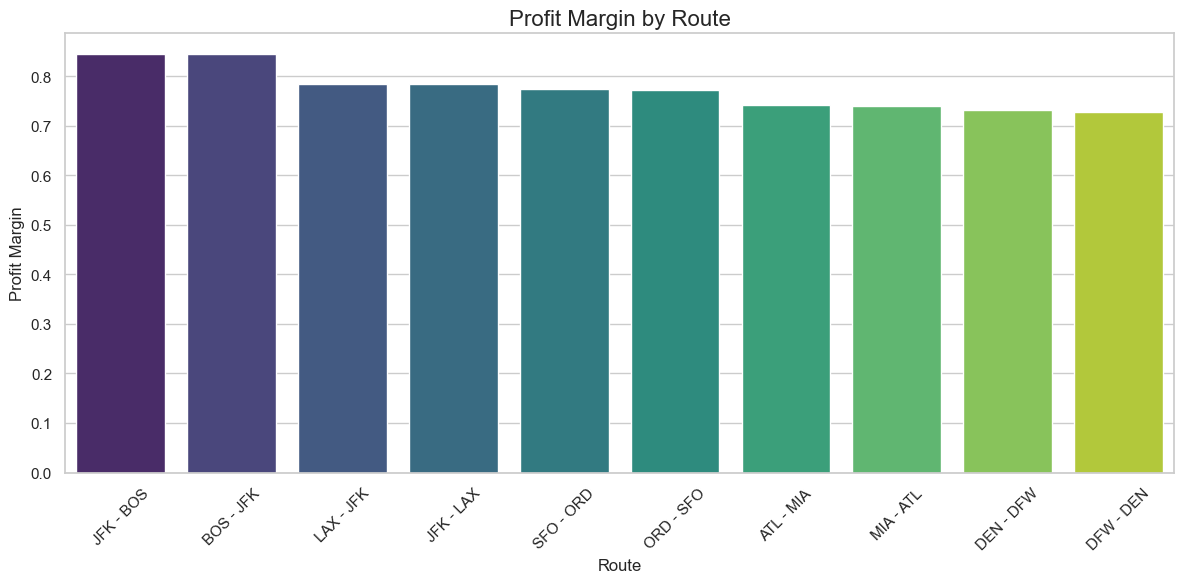

In [4]:
# Plot 1: Profit Margin by Route
plt.figure(figsize=(12, 6))
sns.barplot(data=route_profit, x='RouteName', y='ProfitMargin', palette='viridis')
plt.title('Profit Margin by Route', fontsize=16)
plt.ylabel('Profit Margin', fontsize=12)
plt.xlabel('Route', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'profit_margin_by_route.png'))
plt.show()

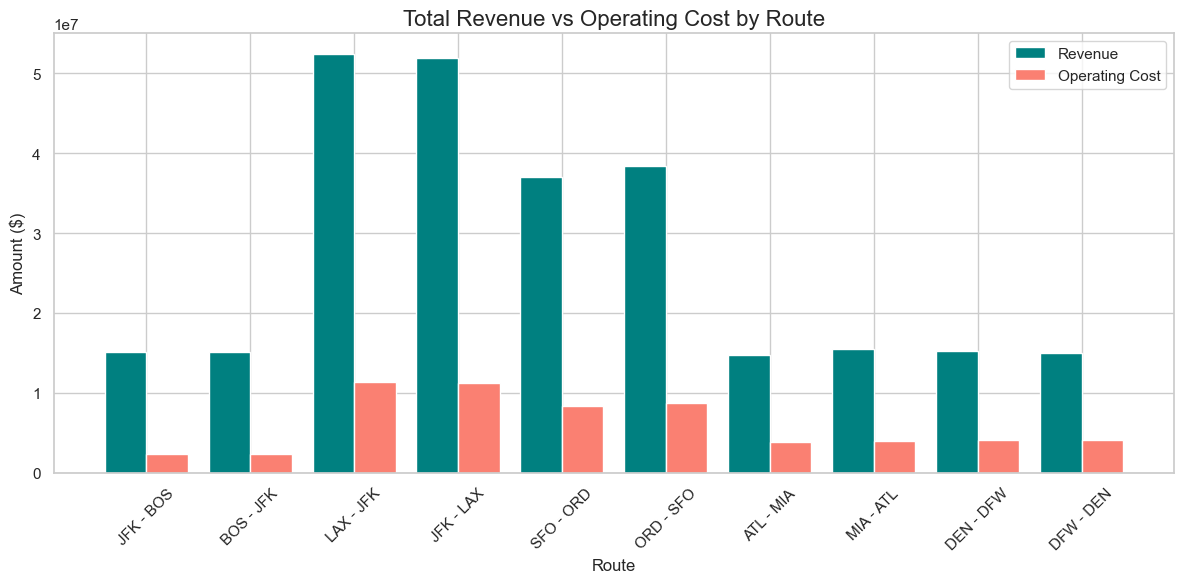

Route profitability analysis complete and figures saved.


In [5]:
# Plot 2: Revenue vs Operating Cost
plt.figure(figsize=(12, 6))
x = range(len(route_profit))
width = 0.4

plt.bar([i - width/2 for i in x], route_profit['TotalRevenue'], width=width, label='Revenue', color='teal')
plt.bar([i + width/2 for i in x], route_profit['TotalOperatingCost'], width=width, label='Operating Cost', color='salmon')

plt.title('Total Revenue vs Operating Cost by Route', fontsize=16)
plt.ylabel('Amount ($)', fontsize=12)
plt.xlabel('Route', fontsize=12)
plt.xticks(x, route_profit['RouteName'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'revenue_vs_cost_by_route.png'))
plt.show()

print("Route profitability analysis complete and figures saved.")